# Topological Alignment: where we are and what comes next

This dashboard turns the current research programme into a visual map. It separates:

1. what has been formalized;
2. what has worked in constructed simulations;
3. what the ablations say is actually necessary; and
4. what the next multi-agent experiment must identify.

> **Epistemic boundary:** none of the plots below constitute evidence that human virtues have this structure or that the simulated goodness target is moral truth. They summarize finite models and constructed simulations.

In [1]:
from pathlib import Path
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display, HTML

ROOT = Path.cwd()
while not (ROOT / 'benchmarks').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not (ROOT / 'benchmarks').exists():
    raise RuntimeError('Run this notebook inside the topological-alignment repository.')

def load_json(relative):
    return json.loads((ROOT / relative).read_text(encoding='utf-8'))

single = load_json('benchmarks/v2_virtue_attractor_results.json')
robust = load_json('benchmarks/v2_robustness_sweep_results.json')

NAVY = '#17324d'
BLUE = '#2878b5'
TEAL = '#2a9d8f'
GOLD = '#e9c46a'
ORANGE = '#f4a261'
RED = '#d65a4a'
GREY = '#d9e1e8'
DARK_GREY = '#52616b'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold', 'axes.labelcolor': NAVY, 'text.color': NAVY})

display(HTML('''
<style>
.dashboard-card {display:inline-block; width:21%; min-width:170px; margin:6px; padding:14px;
 border-radius:10px; background:#f3f7fa; border-left:6px solid #2878b5; vertical-align:top;}
.dashboard-card .big {font-size:27px; font-weight:700; color:#17324d;}
.dashboard-card .small {color:#52616b;}
.callout {padding:14px 18px; background:#fff8e5; border-left:6px solid #e9c46a; border-radius:8px;}
table {font-size: 0.94em;}
</style>
<div class='dashboard-card'><div class='big'>V0–V3</div><div class='small'>constructed stages completed</div></div>
<div class='dashboard-card'><div class='big'>41 / 48</div><div class='small'>robust configurations</div></div>
<div class='dashboard-card'><div class='big'>3</div><div class='small'>independent environments per configuration</div></div>
<div class='dashboard-card'><div class='big'>V4 next</div><div class='small'>shared meaning + cooperation</div></div>
'''))

## 1. The central idea

A recurring, stable state is not automatically a virtue. The working hypothesis is that a virtue is a **selectively stable calibration process**: it organizes meaning and action relative to felt goodness, resists low-quality noise, but changes when reliable evidence shows that its consequences undermine phenotype-relative enablingness.

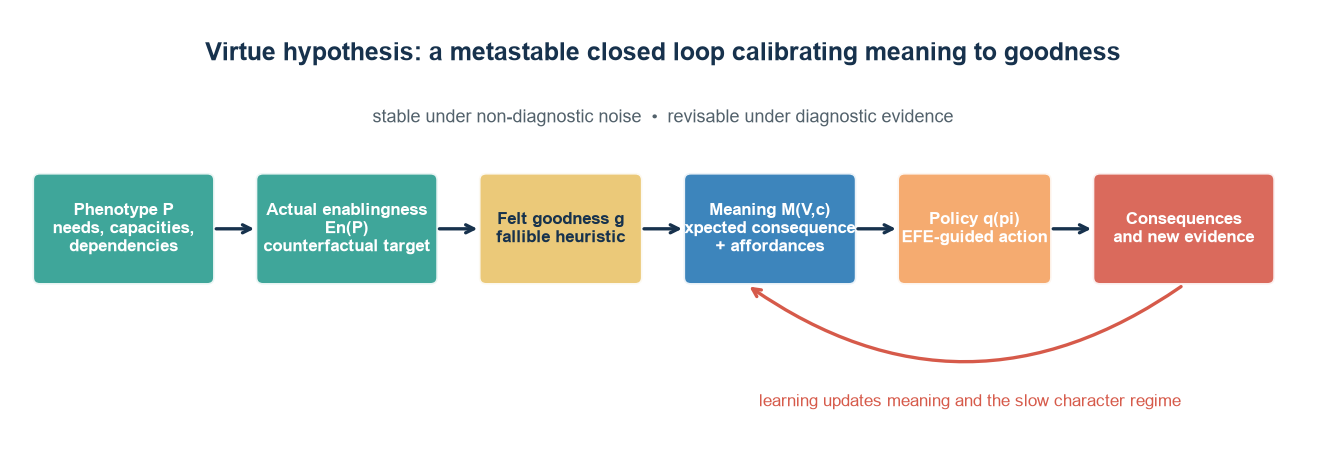

In [2]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')
nodes = [
    (0.3, 2.0, 1.8, 1.1, 'Phenotype P\nneeds, capacities,\ndependencies', TEAL),
    (2.7, 2.0, 1.8, 1.1, 'Actual enablingness\nEn(P)\ncounterfactual target', TEAL),
    (5.1, 2.0, 1.6, 1.1, 'Felt goodness g\nfallible heuristic', GOLD),
    (7.3, 2.0, 1.7, 1.1, 'Meaning M(V,c)\nexpected consequences\n+ affordances', BLUE),
    (9.6, 2.0, 1.5, 1.1, 'Policy q(pi)\nEFE-guided action', ORANGE),
    (11.7, 2.0, 1.8, 1.1, 'Consequences\nand new evidence', RED),
]
for x, y, w, h, label, color in nodes:
    ax.add_patch(patches.FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.08',facecolor=color,edgecolor='white',linewidth=2,alpha=.9))
    ax.text(x+w/2,y+h/2,label,ha='center',va='center',fontsize=10,color='white' if color not in [GOLD] else NAVY,fontweight='bold')
for i in range(len(nodes)-1):
    x1 = nodes[i][0] + nodes[i][2]; x2 = nodes[i+1][0]
    ax.annotate('', xy=(x2-0.06,2.55), xytext=(x1+0.06,2.55), arrowprops=dict(arrowstyle='->',lw=2,color=NAVY))
ax.annotate('', xy=(7.9,1.92), xytext=(12.6,1.92), arrowprops=dict(arrowstyle='->',lw=2,color=RED,connectionstyle='arc3,rad=-.35'))
ax.text(10.3,.55,'learning updates meaning and the slow character regime',ha='center',fontsize=10,color=RED)
ax.text(7,4.45,'Virtue hypothesis: a metastable closed loop calibrating meaning to goodness',ha='center',fontsize=15,fontweight='bold',color=NAVY)
ax.text(7,3.75,'stable under non-diagnostic noise  •  revisable under diagnostic evidence',ha='center',fontsize=11,color=DARK_GREY)
plt.show()

## 2. Evidence ladder

The programme is deliberately staged. Topology is downstream: we first need identifiable constructs for goodness, meaning, and cooperation.

In [3]:
ladder = pd.DataFrame([
    ['V0', 'Felt goodness measurement', 'Can feeling be separated from reward, approval, prediction and justification?', 'Constructed design recovery', 'Human item pilot'],
    ['V1', 'Goodness target', 'Can EFE-derived feeling track counterfactual multi-scale enablingness and fail under capture?', 'Finite simulation passed', 'Multi-agent affected set'],
    ['V2/V3', 'Virtue dynamics', 'Can meaning resist noise yet transform under reliable evidence?', 'Robust constructed signature', 'Identify unique mechanism'],
    ['V4', 'Shared meaning + cooperation', 'Do heterogeneous meanings translate and cause jointly enabling outcomes?', 'NEXT', 'Build identified dyadic model'],
    ['V5', 'Counterfeit virtue', 'Can we separate virtue from stable exploitation, domination and lock-in?', 'Planned', 'Adversarial cases'],
    ['V6', 'Social attractors', 'How do public concepts and local realization co-evolve?', 'Planned', 'Longitudinal simulation/data'],
    ['V7', 'Topological generalization', 'Does decorated topology outperform semantic and dynamical baselines?', 'Deferred', 'Only after V4–V6'],
], columns=['Stage','Construct','Question','Current evidence','Next gate'])

def colour_status(value):
    if value == 'NEXT': return 'background-color:#e9c46a; font-weight:bold'
    if 'passed' in value.lower() or 'robust' in value.lower() or 'recovery' in value.lower(): return 'background-color:#dff3ed'
    if value in ['Planned','Deferred']: return 'background-color:#edf1f4'
    return ''
display(ladder.style.map(colour_status, subset=['Current evidence']).hide(axis='index').set_properties(**{'text-align':'left'}))

Stage,Construct,Question,Current evidence,Next gate
V0,Felt goodness measurement,"Can feeling be separated from reward, approval, prediction and justification?",Constructed design recovery,Human item pilot
V1,Goodness target,Can EFE-derived feeling track counterfactual multi-scale enablingness and fail under capture?,Finite simulation passed,Multi-agent affected set
V2/V3,Virtue dynamics,Can meaning resist noise yet transform under reliable evidence?,Robust constructed signature,Identify unique mechanism
V4,Shared meaning + cooperation,Do heterogeneous meanings translate and cause jointly enabling outcomes?,NEXT,Build identified dyadic model
V5,Counterfeit virtue,"Can we separate virtue from stable exploitation, domination and lock-in?",Planned,Adversarial cases
V6,Social attractors,How do public concepts and local realization co-evolve?,Planned,Longitudinal simulation/data
V7,Topological generalization,Does decorated topology outperform semantic and dynamical baselines?,Deferred,Only after V4–V6


## 3. What the single-setting V2/V3 experiment showed

Four authored regimes were compared. The calibrated regime should be accurate, stable under weak evidence, and transform under strong counterevidence. Dogmatism should return to its old centre; instability should move under noise; opportunism should track reward and approval rather than enablingness.

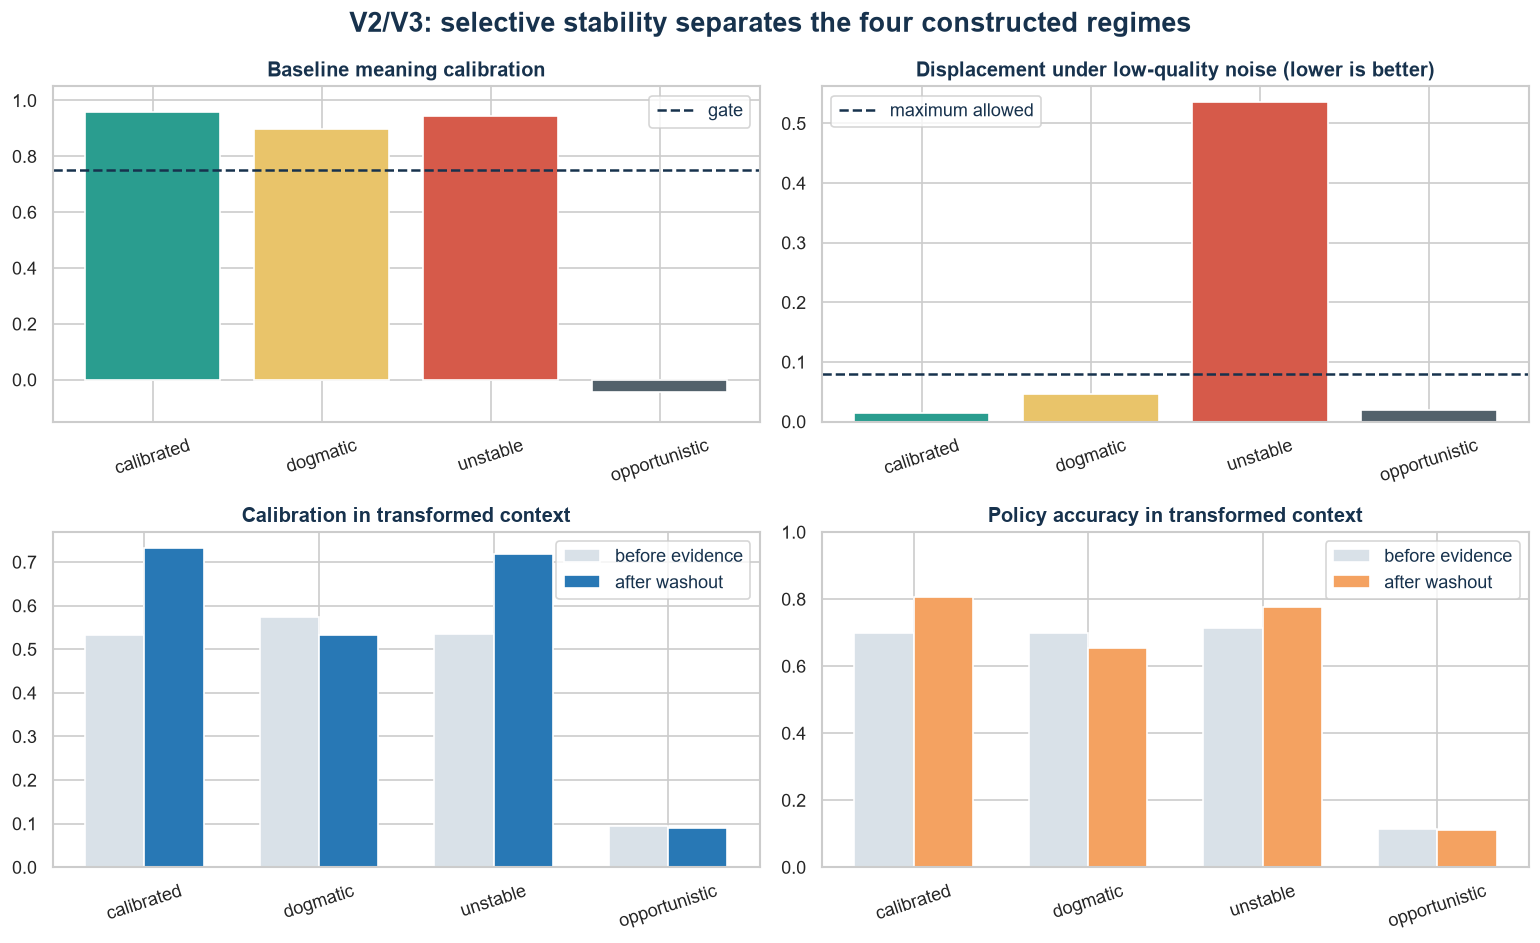

In [4]:
metrics = pd.DataFrame(single['primary_results']).T
regimes = ['calibrated','dogmatic','unstable','opportunistic']
colors = [TEAL, GOLD, RED, DARK_GREY]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].bar(regimes, metrics.loc[regimes,'baseline_calibration'], color=colors)
axes[0,0].axhline(.75,color=NAVY,linestyle='--',label='gate')
axes[0,0].set_title('Baseline meaning calibration'); axes[0,0].set_ylim(-.15,1.05); axes[0,0].legend()

axes[0,1].bar(regimes, metrics.loc[regimes,'noise_displacement'], color=colors)
axes[0,1].axhline(.08,color=NAVY,linestyle='--',label='maximum allowed')
axes[0,1].set_title('Displacement under low-quality noise (lower is better)'); axes[0,1].legend()

x=np.arange(len(regimes)); width=.34
axes[1,0].bar(x-width/2,metrics.loc[regimes,'trap_calibration_before'],width,label='before evidence',color=GREY)
axes[1,0].bar(x+width/2,metrics.loc[regimes,'trap_calibration_retained'],width,label='after washout',color=BLUE)
axes[1,0].set_xticks(x,regimes); axes[1,0].set_title('Calibration in transformed context'); axes[1,0].legend()

axes[1,1].bar(x-width/2,metrics.loc[regimes,'trap_policy_accuracy_before'],width,label='before evidence',color=GREY)
axes[1,1].bar(x+width/2,metrics.loc[regimes,'trap_policy_accuracy_retained'],width,label='after washout',color=ORANGE)
axes[1,1].set_xticks(x,regimes); axes[1,1].set_ylim(0,1); axes[1,1].set_title('Policy accuracy in transformed context'); axes[1,1].legend()

for ax in axes.flat: ax.tick_params(axis='x',rotation=18)
fig.suptitle('V2/V3: selective stability separates the four constructed regimes',fontsize=16,fontweight='bold')
fig.tight_layout(); plt.show()

### Intuition

- **Calibrated:** barely moves under noise, but retains a useful transformation after strong evidence.
- **Dogmatic:** looks reasonably stable, but its slow centre does not revise enough.
- **Unstable:** learns the diagnostic case, but also moves dramatically under weak noise.
- **Opportunistic:** remains badly calibrated because reward and approval substitute for enablingness.

## 4. Did it only work at one hand-picked parameter setting?

No. Forty-eight parameter configurations were sampled, and each had to pass every gate in three independently generated environments.

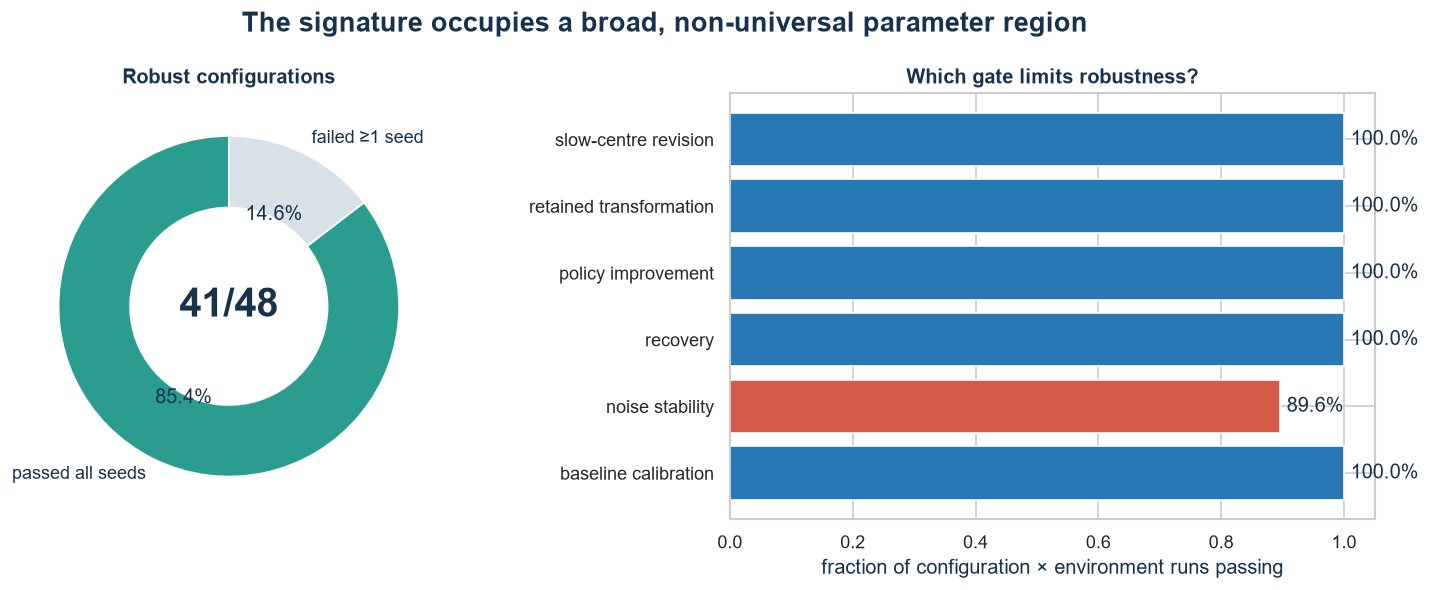

In [5]:
passed = robust['robust_configuration_count']; total = robust['configuration_count']
rates = pd.Series(robust['per_gate_pass_rates']).rename(index={
    'baseline_calibration':'baseline calibration','noise_stability':'noise stability',
    'recovery':'recovery','retained_policy_improvement':'policy improvement',
    'retained_transformation':'retained transformation','slow_centre_revision':'slow-centre revision'})
fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].pie([passed,total-passed],labels=['passed all seeds','failed ≥1 seed'],colors=[TEAL,GREY],autopct='%1.1f%%',startangle=90,wedgeprops={'width':.42,'edgecolor':'white'})
axes[0].text(0,0,f'{passed}/{total}',ha='center',va='center',fontsize=24,fontweight='bold',color=NAVY)
axes[0].set_title('Robust configurations')
bars=axes[1].barh(rates.index,rates.values,color=[RED if v<.95 else BLUE for v in rates.values])
axes[1].set_xlim(0,1.05); axes[1].set_xlabel('fraction of configuration × environment runs passing')
axes[1].set_title('Which gate limits robustness?')
axes[1].bar_label(bars,labels=[f'{v:.1%}' for v in rates.values],padding=4)
fig.suptitle('The signature occupies a broad, non-universal parameter region',fontsize=16,fontweight='bold')
fig.tight_layout(); plt.show()

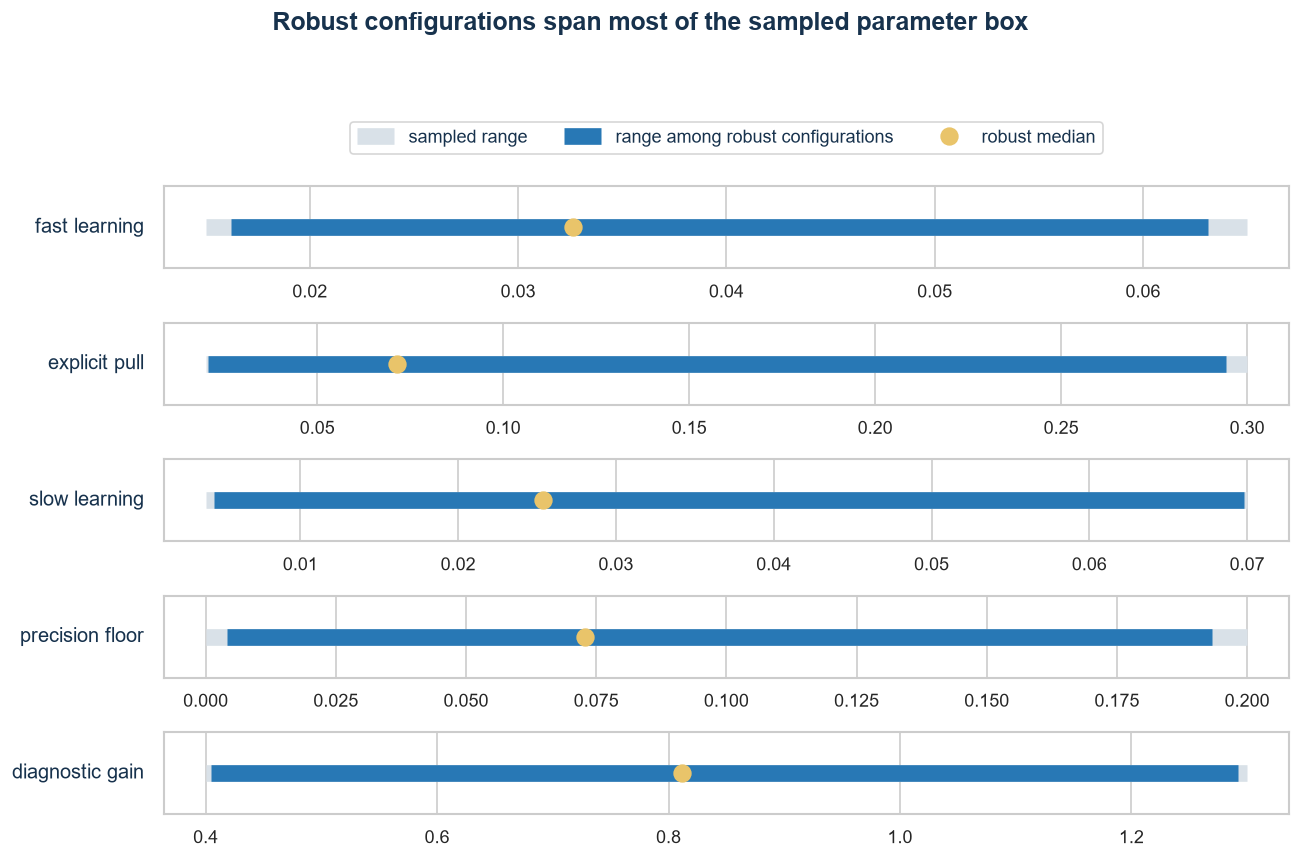

In [6]:
bounds = {
 'fast_learning_rate':(.015,.065), 'attractor_precision':(.02,.30),
 'slow_learning_rate':(.004,.07), 'minimum_evidence_precision':(0,.20),
 'diagnostic_gain':(.40,1.30)}
labels = {'fast_learning_rate':'fast learning','attractor_precision':'explicit pull',
 'slow_learning_rate':'slow learning','minimum_evidence_precision':'precision floor',
 'diagnostic_gain':'diagnostic gain'}
fig, axes = plt.subplots(len(bounds),1,figsize=(11,7))
for ax,(key,(lo,hi)) in zip(axes,bounds.items()):
    region=robust['robust_parameter_region'][key]; span=hi-lo
    ax.hlines(0,lo,hi,color=GREY,lw=10,label='sampled range')
    ax.hlines(0,region['min'],region['max'],color=BLUE,lw=10,label='range among robust configurations')
    ax.plot(region['median'],0,'o',color=GOLD,markersize=10,label='robust median')
    ax.set_xlim(lo-.04*span,hi+.04*span); ax.set_yticks([]); ax.set_ylabel(labels[key],rotation=0,ha='right',va='center',labelpad=12)
axes[0].legend(loc='upper center',bbox_to_anchor=(.5,1.9),ncol=3)
fig.suptitle('Robust configurations span most of the sampled parameter box',fontsize=15,fontweight='bold',y=1.02)
fig.tight_layout(); plt.show()

## 5. Which mechanisms are actually necessary?

Each row removes one component from the calibrated model. Cells show the fraction of three environments in which each gate still passed. A red cell identifies what broke.

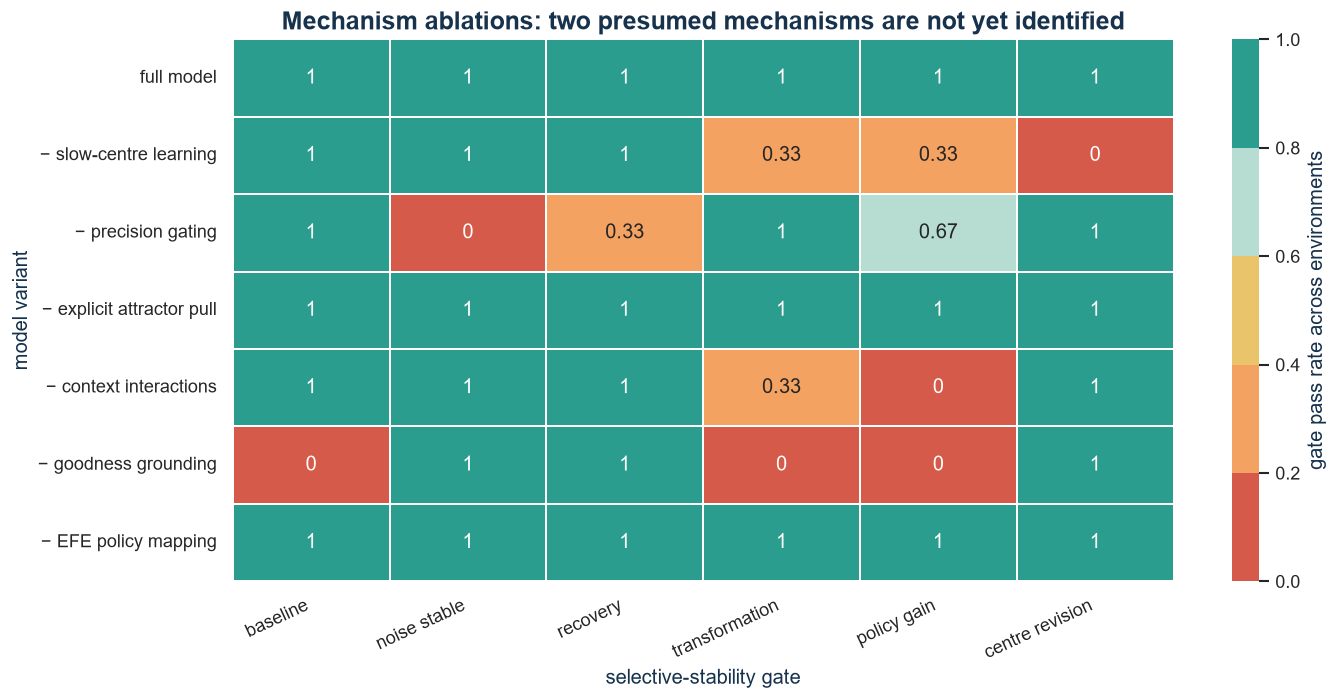

In [7]:
ablation_labels = {
 'full_model':'full model','no_slow_centre_learning':'− slow-centre learning',
 'no_precision_gating':'− precision gating','no_attractor':'− explicit attractor pull',
 'no_context_interactions':'− context interactions','no_goodness_grounding':'− goodness grounding',
 'no_efe_policy_mapping':'− EFE policy mapping'}
gate_labels = {
 'baseline_calibration':'baseline','noise_stability':'noise stable','recovery':'recovery',
 'retained_transformation':'transformation','retained_policy_improvement':'policy gain',
 'slow_centre_revision':'centre revision'}
ablation_df = pd.DataFrame({ablation_labels[k]:v['gate_pass_rates'] for k,v in robust['ablations'].items()}).T
ablation_df = ablation_df.rename(columns=gate_labels)
plt.figure(figsize=(12,6))
sns.heatmap(ablation_df,annot=True,fmt='.2g',vmin=0,vmax=1,cmap=sns.color_palette(['#d65a4a','#f4a261','#e9c46a','#b7ddd3','#2a9d8f'],as_cmap=True),linewidths=1,cbar_kws={'label':'gate pass rate across environments'})
plt.title('Mechanism ablations: two presumed mechanisms are not yet identified',fontsize=15,fontweight='bold')
plt.xlabel('selective-stability gate'); plt.ylabel('model variant'); plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

In [8]:
claims = pd.DataFrame([
 ['Supported in this simulation','Slow-centre learning','Needed for retained transformation and centre revision'],
 ['Supported in this simulation','Evidence-precision gating','Needed to resist low-quality noise'],
 ['Supported in this simulation','Context-sensitive meaning','Needed for retained policy improvement'],
 ['Supported in this simulation','Goodness-grounding','Needed for calibration to enablingness'],
 ['Not identified as necessary','Explicit attractor pull','Removing it still passed 3/3 environments'],
 ['Not identified as necessary','EFE policy mapping','A direct value-policy mapping still passed 3/3'],
 ['Not tested','Human virtue or moral truth','No human data and an authored goodness target'],
],columns=['Status','Claim','Reason'])
def claim_colour(v):
    return {'Supported in this simulation':'background-color:#dff3ed','Not identified as necessary':'background-color:#fff0cf','Not tested':'background-color:#edf1f4'}.get(v,'')
display(claims.style.map(claim_colour,subset=['Status']).hide(axis='index').set_properties(**{'text-align':'left'}))

Status,Claim,Reason
Supported in this simulation,Slow-centre learning,Needed for retained transformation and centre revision
Supported in this simulation,Evidence-precision gating,Needed to resist low-quality noise
Supported in this simulation,Context-sensitive meaning,Needed for retained policy improvement
Supported in this simulation,Goodness-grounding,Needed for calibration to enablingness
Not identified as necessary,Explicit attractor pull,Removing it still passed 3/3 environments
Not identified as necessary,EFE policy mapping,A direct value-policy mapping still passed 3/3
Not tested,Human virtue or moral truth,No human data and an authored goodness target


<div class='callout'><b>The important correction:</b> we currently have evidence for a robust <i>selective-stability signature</i>, not evidence that an explicit mathematical pull term creates an attractor, nor that EFE is uniquely required. The next models must make those mechanisms earn their explanatory role.</div>

## 6. How the other projects fit

This repository is the normative and dynamical integration layer. The sibling projects supply complementary measurements and environments.

In [9]:
projects = pd.DataFrame([
 ['topological-alignment','Goodness target + virtue calibration','Defines what joint dynamics must be calibrated against','Current integration layer'],
 ['shared-protention-alignment','Cross-frame processability + sheaf gluing','Formal test of shared meaning without identical beliefs','Direct V4 dependency'],
 ['externalization-horizon','Externalization + reciprocal readability','Tests whether meanings are observable and inferable','Direct V4 dependency'],
 ['empathy-prisonner-dilemma','Joint outcomes + exploitability','Separates mutual benefit from unilateral exploitation','First V4 task substrate'],
 ['Active_Inference_Social_Lock_In','Norms, precision and stable lock-in','Stable-but-uncalibrated negative control','V4/V6 adversary'],
 ['group-formation/tom','Shared scripts + post-shock identity','Social emergence and longitudinal group dynamics','V6 substrate'],
 ['aif-meta-cogames','Roles, strangers + ecological complementarity','Tests generalization in a richer world','Later ecological test'],
],columns=['Project','Contribution','Why it matters','Role'])
display(projects.style.hide(axis='index').set_properties(**{'text-align':'left'}))

Project,Contribution,Why it matters,Role
topological-alignment,Goodness target + virtue calibration,Defines what joint dynamics must be calibrated against,Current integration layer
shared-protention-alignment,Cross-frame processability + sheaf gluing,Formal test of shared meaning without identical beliefs,Direct V4 dependency
externalization-horizon,Externalization + reciprocal readability,Tests whether meanings are observable and inferable,Direct V4 dependency
empathy-prisonner-dilemma,Joint outcomes + exploitability,Separates mutual benefit from unilateral exploitation,First V4 task substrate
Active_Inference_Social_Lock_In,"Norms, precision and stable lock-in",Stable-but-uncalibrated negative control,V4/V6 adversary
group-formation/tom,Shared scripts + post-shock identity,Social emergence and longitudinal group dynamics,V6 substrate
aif-meta-cogames,"Roles, strangers + ecological complementarity",Tests generalization in a richer world,Later ecological test


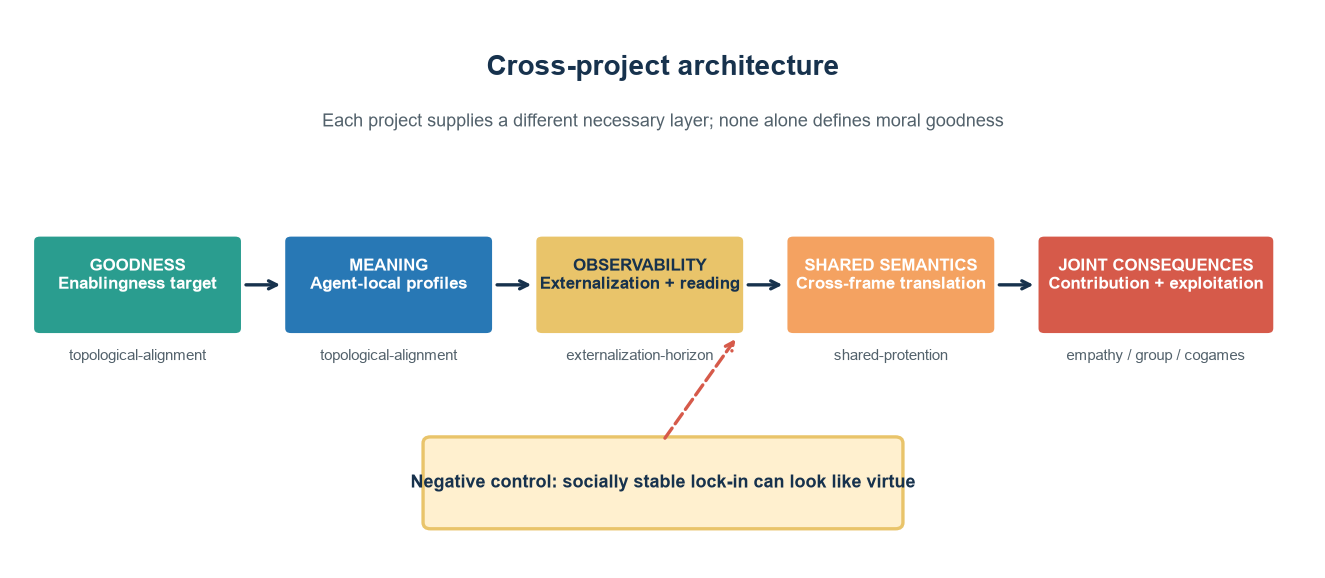

In [10]:
fig, ax = plt.subplots(figsize=(14,6))
ax.set_xlim(0,14); ax.set_ylim(0,7); ax.axis('off')
flow = [
 (0.3,3.0,2.1,1.1,'GOODNESS\nEnablingness target','topological-alignment',TEAL),
 (3.0,3.0,2.1,1.1,'MEANING\nAgent-local profiles','topological-alignment',BLUE),
 (5.7,3.0,2.1,1.1,'OBSERVABILITY\nExternalization + reading','externalization-horizon',GOLD),
 (8.4,3.0,2.1,1.1,'SHARED SEMANTICS\nCross-frame translation','shared-protention',ORANGE),
 (11.1,3.0,2.4,1.1,'JOINT CONSEQUENCES\nContribution + exploitation','empathy / group / cogames',RED)]
for x,y,w,h,title,repo,color in flow:
    ax.add_patch(patches.FancyBboxPatch((x,y),w,h,boxstyle='round,pad=.08',facecolor=color,edgecolor='white',lw=2))
    ax.text(x+w/2,y+.67,title,ha='center',va='center',fontsize=10,fontweight='bold',color='white' if color!=GOLD else NAVY)
    ax.text(x+w/2,y-.35,repo,ha='center',va='center',fontsize=9,color=DARK_GREY)
for i in range(len(flow)-1):
    ax.annotate('',xy=(flow[i+1][0]-.08,3.55),xytext=(flow[i][0]+flow[i][2]+.08,3.55),arrowprops=dict(arrowstyle='->',lw=2,color=NAVY))
ax.add_patch(patches.FancyBboxPatch((4.5,.55),5.0,1.0,boxstyle='round,pad=.08',facecolor='#fff0cf',edgecolor=GOLD,lw=2))
ax.text(7,1.05,'Negative control: socially stable lock-in can look like virtue',ha='center',va='center',fontsize=11,fontweight='bold')
ax.annotate('',xy=(7.8,2.9),xytext=(7,1.58),arrowprops=dict(arrowstyle='->',lw=2,color=RED,linestyle='--'))
ax.text(7,6.2,'Cross-project architecture',ha='center',fontsize=17,fontweight='bold')
ax.text(7,5.55,'Each project supplies a different necessary layer; none alone defines moral goodness',ha='center',fontsize=11,color=DARK_GREY)
plt.show()

## 7. The next decisive experiment: V4

V4 should independently manipulate shared signs, semantic compatibility, causal coupling, and phenotype-relative outcomes. This prevents us from building “cooperation” into an action label.

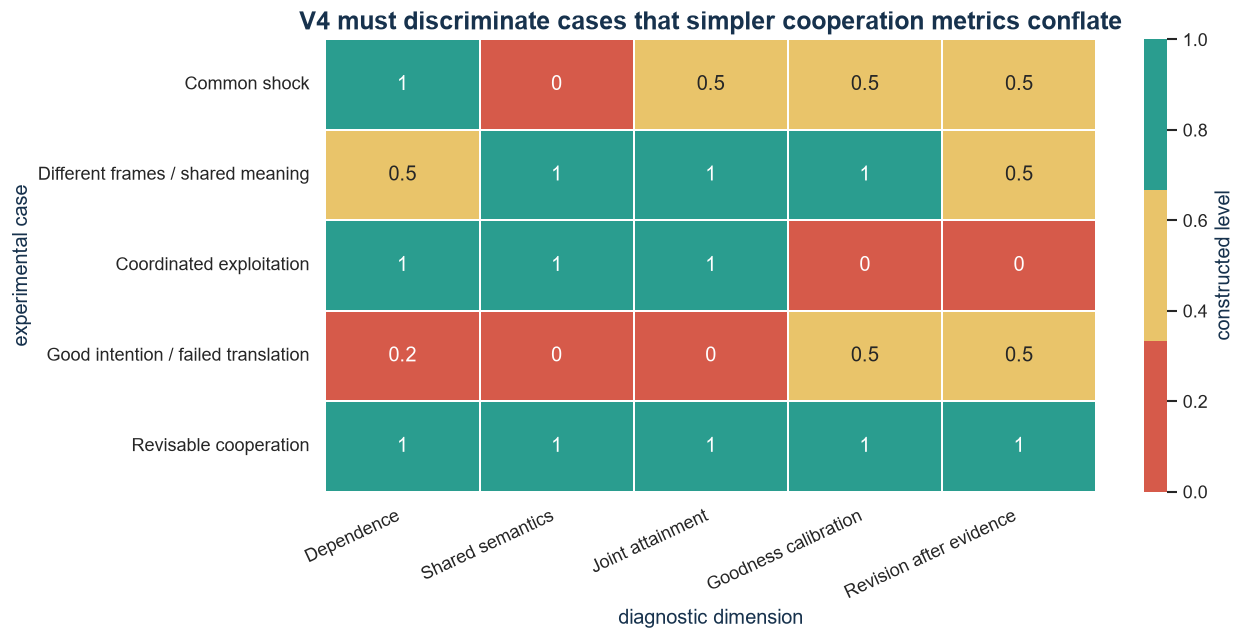

In [11]:
cases = pd.DataFrame({
 'Dependence':[1,.5,1,.2,1],
 'Shared semantics':[0,1,1,0,1],
 'Joint attainment':[.5,1,1,0,1],
 'Goodness calibration':[.5,1,0,.5,1],
 'Revision after evidence':[.5,.5,0,.5,1],
},index=['Common shock','Different frames / shared meaning','Coordinated exploitation','Good intention / failed translation','Revisable cooperation'])
plt.figure(figsize=(11,5.5))
sns.heatmap(cases,annot=True,fmt='.1g',vmin=0,vmax=1,cmap=sns.color_palette(['#d65a4a','#e9c46a','#2a9d8f'],as_cmap=True),linewidths=1,cbar_kws={'label':'constructed level'})
plt.title('V4 must discriminate cases that simpler cooperation metrics conflate',fontsize=15,fontweight='bold')
plt.xlabel('diagnostic dimension'); plt.ylabel('experimental case'); plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

In [12]:
v4 = pd.DataFrame([
 ['Shared sign evidence','Did both agents infer a common sign rather than merely share a label?','Posterior evidence for latent sign z(V)'],
 ['Reciprocal processability','Can each anticipation be translated into the other frame on held-out cases?','min Proc(i→j)'],
 ['Reciprocal readability','Can each agent infer the other without bias or scale error?','min coefficient of determination'],
 ['Joint attainment','Did the joint policy produce the declared outcome?','Q(Y in target set)'],
 ['Causal contribution','Did each contribution actually matter?','randomized coupling / intervention contrast'],
 ['Goodness calibration','Were affected phenotypes enabled rather than externalized onto?','calibration of felt g to En(P)'],
 ['Virtue dynamics','Does shared meaning resist noise but revise after hidden harm is revealed?','recovery + retained transformation'],
],columns=['Outcome','Question','Measurement'])
display(v4.style.hide(axis='index').set_properties(**{'text-align':'left'}))

Outcome,Question,Measurement
Shared sign evidence,Did both agents infer a common sign rather than merely share a label?,Posterior evidence for latent sign z(V)
Reciprocal processability,Can each anticipation be translated into the other frame on held-out cases?,min Proc(i→j)
Reciprocal readability,Can each agent infer the other without bias or scale error?,min coefficient of determination
Joint attainment,Did the joint policy produce the declared outcome?,Q(Y in target set)
Causal contribution,Did each contribution actually matter?,randomized coupling / intervention contrast
Goodness calibration,Were affected phenotypes enabled rather than externalized onto?,calibration of felt g to En(P)
Virtue dynamics,Does shared meaning resist noise but revise after hidden harm is revealed?,recovery + retained transformation


## 8. Bottom line

### What we have

A coherent and fairly robust constructed model of **selective semantic stability relative to a goodness target**. It successfully distinguishes calibration, dogmatism, instability, and opportunism.

### What we do not yet have

A uniquely identified attractor mechanism, an EFE-specific explanation, shared semantics inside the V2 model, human evidence, or proof that phenotype-relative enablingness exhausts moral goodness.

### What we do next

Build V4 by combining this repo's goodness/calibration target with processability from `shared-protention-alignment`, readability from `externalization-horizon`, and joint-outcome/exploitability controls from `empathy-prisonner-dilemma`. The decisive prediction is not simply that virtuous agents cooperate more; it is that their **shared meaning remains calibrated to jointly enabling consequences while resisting noise and revising after hidden externalization is revealed**.